# 07 — XGBoost Model Optimization (F1 + MAE)

Systematically optimize the 3-month prediction model from notebook 06.
Each strategy is tested independently, with clear before/after comparisons.

> **Survivorship Bias Note:** Training data consists of current S&P 500 constituents (as of the data pull date). Companies that were in the index during 2020–2025 but were subsequently delisted, acquired, or went bankrupt are excluded. This creates survivorship bias: the model has been trained on companies that survived, which is not representative of the full prediction universe and likely inflates performance estimates modestly. This is a known limitation of using point-in-time index membership for financial ML and is acknowledged for thesis purposes.

**Baseline (from notebook 06):**

| Metric | Score |
|--------|-------|
| Weighted F1 | 0.2612 |
| MAE (class index 0–4) | 1.3651 |
| Features | 22 (19 technical + 3 sentiment) |

**12 Optimization Strategies:**
- **Part A (F1):** Optuna tuning, class weights, sector features, market-relative features, VIX features, sentiment lags, interaction features, feature selection
- **Part B (MAE):** Custom ordinal objective, MAE eval metric, probability calibration, ordinal post-processing

In [54]:
import os
import json
import pickle
import re
import warnings
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import yfinance as yf
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except ImportError:
    raise ImportError("Run in PowerShell: pip install optuna")

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_style("whitegrid")

## 1. Configuration

In [55]:
# ============================================================
# PATHS
# ============================================================
CACHE_DIR = os.path.join(".", "data")
MODEL_DIR = os.path.join("..", "src", "ml", "app", "models")
METADATA_PATH = os.path.join(MODEL_DIR, "training_metadata.json")
OHLCV_CACHE = os.path.join(CACHE_DIR, "sp500_ohlcv_5y.parquet")
GDELT_CACHE = os.path.join(CACHE_DIR, "gdelt_sentiment_5y.parquet")
STUDY_CACHE = os.path.join(CACHE_DIR, "optuna_study_07.pkl")

# ============================================================
# CONSTANTS
# ============================================================
SIGNAL_LABELS = ["Strong Sell", "Sell", "Hold", "Buy", "Strong Buy"]
THRESHOLDS_3M = (-10, -3, 3, 12)
HORIZON_DAYS_3M = 63
SPLIT_DATE = pd.Timestamp("2025-09-01")
N_OPTUNA_TRIALS = 150

# ============================================================
# FEATURE GROUPS (baseline from notebook 06)
# ============================================================
TECH_FEATURES = [
    "Price_SMA50_Ratio", "Price_SMA200_Ratio", "Price_EMA20_Ratio",
    "MACD_Norm", "MACD_Signal_Norm", "MACD_Hist_Norm",
    "RSI", "Stoch_K", "Stoch_D", "ROC",
    "BB_Position", "BB_Width", "ATR_Pct",
    "OBV_Norm", "Vol_SMA_Ratio",
    "Dist_52w_High", "Dist_52w_Low", "Return_1m", "Return_3m",
]
SENTIMENT_FEATURES = ["sentiment_avg_20d", "sentiment_volume_20d", "sentiment_momentum"]
BASELINE_FEATURES = TECH_FEATURES + SENTIMENT_FEATURES

# Results tracker
results = {}

print(f"Baseline features: {len(BASELINE_FEATURES)} ({len(TECH_FEATURES)} tech + {len(SENTIMENT_FEATURES)} sent)")
print(f"Split date: {SPLIT_DATE.date()}, Optuna trials: {N_OPTUNA_TRIALS}")

Baseline features: 22 (19 tech + 3 sent)
Split date: 2025-09-01, Optuna trials: 150


## 2. Helper Functions

Same feature engineering as notebook 06, plus evaluation utilities.

In [56]:
def compute_features(df: pd.DataFrame) -> pd.DataFrame:
    # Compute all technical indicators (relative ratios/percentages).
    df = df.copy()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Trend
    sma_50 = df["Close"].rolling(50).mean()
    sma_200 = df["Close"].rolling(200).mean()
    ema_20 = df["Close"].ewm(span=20, adjust=False).mean()
    df["Price_SMA50_Ratio"] = df["Close"] / sma_50
    df["Price_SMA200_Ratio"] = df["Close"] / sma_200
    df["Price_EMA20_Ratio"] = df["Close"] / ema_20

    ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
    ema_26 = df["Close"].ewm(span=26, adjust=False).mean()
    macd_raw = ema_12 - ema_26
    macd_sig = macd_raw.ewm(span=9, adjust=False).mean()
    df["MACD_Norm"] = macd_raw / df["Close"] * 100
    df["MACD_Signal_Norm"] = macd_sig / df["Close"] * 100
    df["MACD_Hist_Norm"] = df["MACD_Norm"] - df["MACD_Signal_Norm"]

    # Momentum
    delta = df["Close"].diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    df["RSI"] = 100 - (100 / (1 + avg_gain / avg_loss))

    low_14 = df["Low"].rolling(14).min()
    high_14 = df["High"].rolling(14).max()
    df["Stoch_K"] = 100 * (df["Close"] - low_14) / (high_14 - low_14)
    df["Stoch_D"] = df["Stoch_K"].rolling(3).mean()
    df["ROC"] = df["Close"].pct_change(21) * 100

    # Volatility
    bb_sma = df["Close"].rolling(20).mean()
    bb_std = df["Close"].rolling(20).std()
    bb_upper = bb_sma + 2 * bb_std
    bb_lower = bb_sma - 2 * bb_std
    df["BB_Position"] = (df["Close"] - bb_lower) / (bb_upper - bb_lower)
    df["BB_Width"] = (bb_upper - bb_lower) / bb_sma

    tr = pd.concat([
        df["High"] - df["Low"],
        (df["High"] - df["Close"].shift(1)).abs(),
        (df["Low"] - df["Close"].shift(1)).abs(),
    ], axis=1).max(axis=1)
    df["ATR_Pct"] = tr.rolling(14).mean() / df["Close"] * 100

    # Volume
    obv = (np.sign(df["Close"].diff()) * df["Volume"]).cumsum()
    df["OBV_Norm"] = obv.diff(21) / df["Volume"].rolling(21).mean()
    df["Vol_SMA_Ratio"] = df["Volume"] / df["Volume"].rolling(20).mean()

    # Price-derived
    df["Dist_52w_High"] = (df["Close"] - df["High"].rolling(252).max()) / df["High"].rolling(252).max() * 100
    df["Dist_52w_Low"] = (df["Close"] - df["Low"].rolling(252).min()) / df["Low"].rolling(252).min() * 100
    df["Return_1m"] = df["Close"].pct_change(21) * 100
    df["Return_3m"] = df["Close"].pct_change(63) * 100

    return df


def compute_future_returns(close, horizon_days):
    return (close.shift(-horizon_days) / close - 1) * 100


def assign_signal(returns, thresholds):
    ss, s, b, sb = thresholds
    conditions = [returns < ss, (returns >= ss) & (returns < s),
                  (returns >= s) & (returns < b), (returns >= b) & (returns < sb),
                  returns >= sb]
    return pd.Series(np.select(conditions, SIGNAL_LABELS, default=""),
                     index=returns.index).replace("", np.nan)


def clean_company_name(name):
    name = name.lower().strip().replace(",", " ").replace(".", " ")
    name = re.sub(r"\s+", " ", name).strip()
    name = re.sub(r"^the ", "", name)
    name = re.sub(r"\s*&\s*co\s*$", "", name)
    name = re.sub(
        r"\s+(inc|corp|co|ltd|llc|plc|lp|nv|sa|corporation|incorporated|"
        r"company|companies|holdings|group|enterprises?|international)\s*$",
        "", name)
    return name.strip()


def compute_sentiment_features(scored_df, processed):
    all_features = []
    tickers = scored_df["ticker"].unique()
    for i, ticker in enumerate(tickers, 1):
        if ticker not in processed:
            continue
        daily = scored_df[scored_df["ticker"] == ticker].groupby("date").agg(
            daily_sentiment=("sentiment", "mean"),
            daily_count=("sentiment", "count"),
        )
        trading_dates = processed[ticker].index
        daily_aligned = daily.reindex(trading_dates)
        daily_aligned["daily_sentiment"] = daily_aligned["daily_sentiment"].ffill()
        daily_aligned["daily_count"] = daily_aligned["daily_count"].fillna(0)

        sent_avg_20 = daily_aligned["daily_sentiment"].rolling(20, min_periods=5).mean()
        sent_avg_60 = daily_aligned["daily_sentiment"].rolling(60, min_periods=10).mean()
        sent_vol_20 = daily_aligned["daily_count"].rolling(20, min_periods=1).sum()

        all_features.append(pd.DataFrame({
            "ticker": ticker, "date": trading_dates,
            "sentiment_avg_20d": sent_avg_20.values,
            "sentiment_volume_20d": sent_vol_20.values,
            "sentiment_momentum": (sent_avg_20 - sent_avg_60).values,
        }))
        if i % 100 == 0:
            print(f"  [{i}/{len(tickers)}] tickers")
    return pd.concat(all_features, ignore_index=True)


def eval_model(y_true, y_pred, label="Model"):
    f1 = f1_score(y_true, y_pred, average="weighted")
    acc = accuracy_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{label}: F1={f1:.4f}  Acc={acc:.4f}  MAE={mae:.4f}")
    return {"f1": f1, "acc": acc, "mae": mae}


print("Helper functions loaded.")

Helper functions loaded.


## 3. Load & Prepare Data

Load cached OHLCV and GDELT sentiment data, compute features, and build the baseline 3m dataset.
This replicates the exact pipeline from notebook 06.

In [57]:
# Load OHLCV cache
print("Loading OHLCV data...")
ohlcv_all = pd.read_parquet(OHLCV_CACHE)
all_data = {}
for ticker in ohlcv_all["Ticker"].unique():
    df = ohlcv_all[ohlcv_all["Ticker"] == ticker].drop(columns=["Ticker"])
    df.index = pd.to_datetime(df.index)
    all_data[ticker] = df
print(f"Loaded {len(all_data)} tickers")

# Compute technical features
print("Computing technical features...")
processed = {}
for ticker, df in all_data.items():
    feat = compute_features(df)
    feat = feat.dropna(subset=TECH_FEATURES)
    if len(feat) > 0:
        processed[ticker] = feat
print(f"Computed features for {len(processed)} tickers")

Loading OHLCV data...
Loaded 499 tickers
Computing technical features...
Computed features for 499 tickers


In [58]:
# Load metadata & fetch S&P 500 table (needed for company name mapping + GICS sectors)
with open(METADATA_PATH) as f:
    metadata = json.load(f)
tickers = metadata["training_tickers"]

print("Fetching S&P 500 table from Wikipedia...")
resp = requests.get(
    "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",
    headers={"User-Agent": "StockPredictor/1.0 (thesis)"},
    timeout=15,
)
resp.raise_for_status()
sp500_table = pd.read_html(resp.text)[0]
print(f"Got {len(sp500_table)} companies")

# Build company name -> ticker mapping for GDELT
ticker_to_company = {}
for ticker in tickers:
    row = sp500_table[sp500_table["Symbol"] == ticker]
    if row.empty:
        row = sp500_table[sp500_table["Symbol"] == ticker.replace("-", ".")]
    if not row.empty:
        ticker_to_company[ticker] = clean_company_name(row.iloc[0]["Security"])

company_to_tickers = {}
for ticker, company in ticker_to_company.items():
    company_to_tickers.setdefault(company, []).append(ticker)

# Load GDELT and map to tickers
print("Loading GDELT sentiment data...")
gdelt_df = pd.read_parquet(GDELT_CACHE)
gdelt_df["date"] = pd.to_datetime(gdelt_df["article_date"], format="%Y%m%d")

mapping_rows = []
for company, ticker_list in company_to_tickers.items():
    for ticker in ticker_list:
        mapping_rows.append({"matched_org": company, "ticker": ticker})
mapping_df = pd.DataFrame(mapping_rows)

scored_df = gdelt_df.merge(mapping_df, on="matched_org", how="inner")
scored_df["sentiment"] = np.clip(scored_df["tone"] / 10, -1, 1)
scored_df = scored_df[["ticker", "date", "sentiment"]].copy()
print(f"Scored: {len(scored_df):,} records for {scored_df['ticker'].nunique()} tickers")

# Compute rolling sentiment features
print("\nComputing rolling sentiment features...")
sentiment_features = compute_sentiment_features(scored_df, processed)
print(f"Result: {len(sentiment_features):,} rows for {sentiment_features['ticker'].nunique()} tickers")

Fetching S&P 500 table from Wikipedia...
Got 503 companies
Loading GDELT sentiment data...
Scored: 66,016,919 records for 427 tickers

Computing rolling sentiment features...
  [100/427] tickers
  [200/427] tickers
  [300/427] tickers
  [400/427] tickers
Result: 426,780 rows for 427 tickers


In [59]:
# Build 3m labeled dataset (same logic as notebook 06)
print("Building 3m labeled dataset...")
datasets = []
for ticker, df in processed.items():
    future_ret = compute_future_returns(df["Close"], HORIZON_DAYS_3M)
    signals = assign_signal(future_ret, THRESHOLDS_3M)
    subset = df[TECH_FEATURES].copy()
    subset["Signal"] = signals
    subset["Ticker"] = ticker
    subset = subset.dropna(subset=TECH_FEATURES + ["Signal"])
    if len(subset) > 0:
        datasets.append(subset)

df_3m = pd.concat(datasets)

# Merge sentiment features
sentiment_features["date"] = pd.to_datetime(sentiment_features["date"])
df_3m = df_3m.reset_index()
date_col = "Date" if "Date" in df_3m.columns else df_3m.columns[0]
df_3m = df_3m.rename(columns={date_col: "date"})
df_3m["date"] = pd.to_datetime(df_3m["date"])

df_3m = df_3m.merge(
    sentiment_features[["ticker", "date"] + SENTIMENT_FEATURES],
    left_on=["Ticker", "date"],
    right_on=["ticker", "date"],
    how="left",
).drop(columns=["ticker"], errors="ignore")

df_3m = df_3m.set_index("date").sort_index()

print(f"Dataset: {len(df_3m):,} samples, {df_3m['Ticker'].nunique()} tickers")
print(f"Date range: {df_3m.index.min().date()} to {df_3m.index.max().date()}")

# Class distribution
print(f"\nClass distribution:")
counts = df_3m["Signal"].value_counts().reindex(SIGNAL_LABELS)
for label, count in zip(SIGNAL_LABELS, counts):
    pct = count / len(df_3m) * 100
    print(f"  {label:>12}: {int(count):6,} ({pct:5.1f}%)")

Building 3m labeled dataset...
Dataset: 467,631 samples, 499 tickers
Date range: 2022-03-23 to 2025-12-19

Class distribution:
   Strong Sell: 77,271 ( 16.5%)
          Sell: 77,464 ( 16.6%)
          Hold: 82,560 ( 17.7%)
           Buy: 112,164 ( 24.0%)
    Strong Buy: 118,172 ( 25.3%)


## 4. Verify Baseline

Train the same model as notebook 06 (22 features, default XGBoost params) and confirm
F1 and MAE match before proceeding with optimizations.

In [60]:
# Train/test split
le = LabelEncoder()
le.fit(SIGNAL_LABELS)

train = df_3m[df_3m.index < SPLIT_DATE].copy()
test = df_3m[df_3m.index >= SPLIT_DATE].copy()

y_train = le.transform(train["Signal"])
y_test = le.transform(test["Signal"])

# Class weights (inverse frequency)
class_counts = Counter(y_train)
total = len(y_train)
n_classes = len(SIGNAL_LABELS)
class_weights_dict = {cls: total / (n_classes * count) for cls, count in class_counts.items()}
sample_weights = np.array([class_weights_dict[y] for y in y_train])

X_train_base = train[BASELINE_FEATURES]
X_test_base = test[BASELINE_FEATURES]

# Train baseline (same params as notebook 06)
baseline_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    objective="multi:softprob", num_class=n_classes,
    eval_metric="mlogloss", random_state=42, n_jobs=-1,
)
baseline_model.fit(X_train_base, y_train, sample_weight=sample_weights)

# Evaluate
y_pred_base = baseline_model.predict(X_test_base)
base_metrics = eval_model(y_test, y_pred_base, "Baseline (tech+sentiment)")

results["1_baseline"] = {
    "desc": "Baseline (tech + sentiment, default params)",
    "n_features": len(BASELINE_FEATURES), **base_metrics,
}

print(f"\nExpected: F1~0.2612, MAE~1.3651")
print(f"Train: {len(X_train_base):,}  Test: {len(X_test_base):,}")
print(f"\n{classification_report(y_test, y_pred_base, target_names=SIGNAL_LABELS, zero_division=0)}")

Baseline (tech+sentiment): F1=0.2645  Acc=0.2646  MAE=1.3515

Expected: F1~0.2612, MAE~1.3651
Train: 428,713  Test: 38,918

              precision    recall  f1-score   support

 Strong Sell       0.27      0.22      0.24      8415
        Sell       0.23      0.24      0.24      6391
        Hold       0.19      0.20      0.20      6087
         Buy       0.34      0.34      0.34     11254
  Strong Buy       0.24      0.28      0.26      6771

    accuracy                           0.26     38918
   macro avg       0.25      0.26      0.25     38918
weighted avg       0.27      0.26      0.26     38918



## 5. New Features (Strategies 3–7)

Add five groups of features to the dataset, then retrain with default params as a sanity check.

| Strategy | Features | Count |
|----------|----------|-------|
| 3. GICS Sector | One-hot encoded sectors | 11 |
| 4. Market-Relative | Excess returns, relative RSI/volume, SPY returns | 6 |
| 5. VIX / Regime | VIX percentile, VIX momentum, market regime | 3 |
| 6. Sentiment Lags | Lagged sentiment, trend, std | 4 |
| 7. Interactions | Sentiment x technical cross-features | 3 |

### 5a. Strategy 3 — GICS Sector Features

In [61]:
# GICS Sector one-hot encoding (11 sectors)
print("Strategy 3: GICS Sector Features")
print("=" * 50)

ticker_to_sector = {}
for ticker in tickers:
    row = sp500_table[sp500_table["Symbol"] == ticker]
    if row.empty:
        row = sp500_table[sp500_table["Symbol"] == ticker.replace("-", ".")]
    if not row.empty:
        ticker_to_sector[ticker] = row.iloc[0]["GICS Sector"]

df_3m["sector"] = df_3m["Ticker"].map(ticker_to_sector)
sector_dummies = pd.get_dummies(df_3m["sector"], prefix="sector", dtype=float)
SECTOR_FEATURES = sorted(sector_dummies.columns.tolist())
df_3m = pd.concat([df_3m, sector_dummies], axis=1)
df_3m = df_3m.drop(columns=["sector"])

print(f"Sectors: {len(SECTOR_FEATURES)}")
for feat in SECTOR_FEATURES:
    name = feat.replace("sector_", "")
    n = int(df_3m[feat].sum())
    print(f"  {name:30s}: {n:>7,} samples ({n/len(df_3m)*100:.1f}%)")

Strategy 3: GICS Sector Features
Sectors: 11
  Communication Services        :  20,702 samples (4.4%)
  Consumer Discretionary        :  45,168 samples (9.7%)
  Consumer Staples              :  32,403 samples (6.9%)
  Energy                        :  20,702 samples (4.4%)
  Financials                    :  71,415 samples (15.3%)
  Health Care                   :  54,142 samples (11.6%)
  Industrials                   :  71,821 samples (15.4%)
  Information Technology        :  64,915 samples (13.9%)
  Materials                     :  24,466 samples (5.2%)
  Real Estate                   :  29,170 samples (6.2%)
  Utilities                     :  28,963 samples (6.2%)


### 5b. Strategy 4 — Market-Relative Features (SPY)

In [62]:
# Download SPY and compute market-relative features
print("Strategy 4: Market-Relative Features")
print("=" * 50)

spy_cache = os.path.join(CACHE_DIR, "spy_5y.parquet")
if os.path.exists(spy_cache):
    spy_raw = pd.read_parquet(spy_cache)
    print("Loaded SPY from cache")
else:
    print("Downloading SPY data (5y)...")
    spy_raw = yf.download("SPY", period="5y", auto_adjust=True)
    spy_raw.to_parquet(spy_cache)
    print("Saved SPY cache")

spy_raw.index = pd.to_datetime(spy_raw.index)
if isinstance(spy_raw.columns, pd.MultiIndex):
    spy_raw.columns = spy_raw.columns.get_level_values(0)

# Compute SPY features using same pipeline
spy_feat = compute_features(spy_raw)

# Merge SPY indicators by date
spy_merge = spy_feat[["RSI", "Vol_SMA_Ratio", "Return_1m", "Return_3m"]].copy()
spy_merge.columns = ["spy_RSI", "spy_Vol_SMA_Ratio", "spy_Return_1m", "spy_Return_3m"]
df_3m = df_3m.join(spy_merge, how="left")

# Relative features
df_3m["excess_return_1m"] = df_3m["Return_1m"] - df_3m["spy_Return_1m"]
df_3m["excess_return_3m"] = df_3m["Return_3m"] - df_3m["spy_Return_3m"]
df_3m["relative_rsi"] = df_3m["RSI"] - df_3m["spy_RSI"]
df_3m["relative_volume"] = df_3m["Vol_SMA_Ratio"] - df_3m["spy_Vol_SMA_Ratio"]
df_3m = df_3m.rename(columns={"spy_Return_1m": "spy_return_1m", "spy_Return_3m": "spy_return_3m"})
df_3m = df_3m.drop(columns=["spy_RSI", "spy_Vol_SMA_Ratio"])

MARKET_FEATURES = [
    "excess_return_1m", "excess_return_3m",
    "relative_rsi", "relative_volume",
    "spy_return_1m", "spy_return_3m",
]

print(f"Market-relative features: {len(MARKET_FEATURES)}")
for f in MARKET_FEATURES:
    print(f"  {f}: mean={df_3m[f].mean():.4f}, NaN={df_3m[f].isna().sum()}")

Strategy 4: Market-Relative Features
Loaded SPY from cache
Market-relative features: 6
  excess_return_1m: mean=-0.1010, NaN=0
  excess_return_3m: mean=-0.2633, NaN=0
  relative_rsi: mean=-3.9688, NaN=0
  relative_volume: mean=0.0066, NaN=0
  spy_return_1m: mean=1.2394, NaN=0
  spy_return_3m: mean=3.3966, NaN=0


### 5c. Strategy 5 — VIX / Market Regime Features

In [63]:
# Download VIX and compute regime features
print("Strategy 5: VIX / Market Regime Features")
print("=" * 50)

vix_cache = os.path.join(CACHE_DIR, "vix_5y.parquet")
if os.path.exists(vix_cache):
    vix_raw = pd.read_parquet(vix_cache)
    print("Loaded VIX from cache")
else:
    print("Downloading VIX data (5y)...")
    vix_raw = yf.download("^VIX", period="5y", auto_adjust=True)
    vix_raw.to_parquet(vix_cache)
    print("Saved VIX cache")

vix_raw.index = pd.to_datetime(vix_raw.index)
if isinstance(vix_raw.columns, pd.MultiIndex):
    vix_raw.columns = vix_raw.columns.get_level_values(0)

# VIX percentile over trailing 252 days (scale-invariant)
vix_close = vix_raw["Close"]
vix_pctl = vix_close.rolling(252, min_periods=63).apply(
    lambda x: (x <= x.iloc[-1]).mean(), raw=False
)

# VIX 20-day change (is fear rising or falling?)
vix_chg = vix_close.pct_change(20)

# Market regime: SPY above 200-day SMA = bull (1), below = bear (0)
spy_sma200 = spy_raw["Close"].rolling(200).mean()
market_regime = (spy_raw["Close"] > spy_sma200).astype(float)

# Combine and merge
vix_feats = pd.DataFrame({
    "vix_level": vix_pctl,
    "vix_change_20d": vix_chg,
}, index=vix_raw.index)
regime_df = pd.DataFrame({"market_regime": market_regime}, index=spy_raw.index)
vix_feats = vix_feats.join(regime_df, how="outer")

df_3m = df_3m.join(vix_feats, how="left")

VIX_FEATURES = ["vix_level", "vix_change_20d", "market_regime"]
print(f"VIX features: {len(VIX_FEATURES)}")
for f in VIX_FEATURES:
    nans = df_3m[f].isna().sum()
    print(f"  {f}: mean={df_3m[f].mean():.4f}, NaN={nans} ({nans/len(df_3m)*100:.1f}%)")

Strategy 5: VIX / Market Regime Features
Loaded VIX from cache
VIX features: 3
  vix_level: mean=0.4593, NaN=0 (0.0%)
  vix_change_20d: mean=0.0137, NaN=0 (0.0%)
  market_regime: mean=0.7500, NaN=0 (0.0%)


### 5d. Strategy 6 — GDELT Sentiment Lag Features

In [64]:
# Sentiment lag features (computed per-ticker from existing sentiment_avg_20d)
print("Strategy 6: Sentiment Lag Features")
print("=" * 50)

SENTIMENT_LAG_FEATURES = [
    "sentiment_avg_20d_lag_5d",
    "sentiment_avg_20d_lag_20d",
    "sentiment_trend_20d",
    "sentiment_std_20d",
]

for col in SENTIMENT_LAG_FEATURES:
    df_3m[col] = np.nan

for ticker in df_3m["Ticker"].unique():
    mask = df_3m["Ticker"] == ticker
    sent = df_3m.loc[mask, "sentiment_avg_20d"]

    df_3m.loc[mask, "sentiment_avg_20d_lag_5d"] = sent.shift(5)
    df_3m.loc[mask, "sentiment_avg_20d_lag_20d"] = sent.shift(20)
    df_3m.loc[mask, "sentiment_trend_20d"] = (sent - sent.shift(20)) / 20
    df_3m.loc[mask, "sentiment_std_20d"] = sent.rolling(20, min_periods=5).std()

print(f"Sentiment lag features: {len(SENTIMENT_LAG_FEATURES)}")
for f in SENTIMENT_LAG_FEATURES:
    valid = df_3m[f].notna().sum()
    print(f"  {f}: {valid:,} valid ({valid/len(df_3m)*100:.1f}%)")

Strategy 6: Sentiment Lag Features
Sentiment lag features: 4
  sentiment_avg_20d_lag_5d: 387,611 valid (82.9%)
  sentiment_avg_20d_lag_20d: 381,251 valid (81.5%)
  sentiment_trend_20d: 381,251 valid (81.5%)
  sentiment_std_20d: 388,035 valid (83.0%)


### 5e. Strategy 7 — Interaction Features (Sentiment x Technical)

In [65]:
# Interaction features: sentiment context matters
print("Strategy 7: Interaction Features")
print("=" * 50)

# Positive sentiment in calm vs volatile markets
df_3m["sentiment_x_volatility"] = df_3m["sentiment_avg_20d"] * df_3m["BB_Width"]

# Positive sentiment + oversold RSI = potential reversal
df_3m["sentiment_x_momentum"] = df_3m["sentiment_avg_20d"] * df_3m["RSI"]

# Are sentiment and price moving together or diverging?
df_3m["sentiment_x_trend"] = df_3m["sentiment_momentum"] * df_3m["Return_1m"]

INTERACTION_FEATURES = [
    "sentiment_x_volatility",
    "sentiment_x_momentum",
    "sentiment_x_trend",
]

print(f"Interaction features: {len(INTERACTION_FEATURES)}")
for f in INTERACTION_FEATURES:
    valid = df_3m[f].notna().sum()
    print(f"  {f}: mean={df_3m[f].mean():.6f}, valid={valid:,}")

Strategy 7: Interaction Features
Interaction features: 3
  sentiment_x_volatility: mean=0.012750, valid=389,731
  sentiment_x_momentum: mean=5.562914, valid=389,731
  sentiment_x_trend: mean=0.021815, valid=387,611


### 5f. Cross-Sectional Rank Features

For each trading date, rank each stock's indicator among all S&P 500 stocks present on that date (percentile, 0=worst, 1=best). Cross-sectional momentum is among the most documented predictors in quantitative finance. These features are leak-free: ranks use only same-day peer data that is fully observable at prediction time.

In [66]:
# Cross-sectional rank features: for each date, rank each stock's indicator
# among all S&P 500 stocks present on that date (percentile: 0=worst, 1=best)
print("Cross-Sectional Rank Features")
print("=" * 50)

RANK_SOURCE_FEATURES = ["RSI", "Return_1m", "Return_3m", "BB_Width", "ATR_Pct", "Vol_SMA_Ratio", "BB_Position"]
RANK_FEATURES = [f"{f}_rank" for f in RANK_SOURCE_FEATURES]

for feat in RANK_SOURCE_FEATURES:
    df_3m[f"{feat}_rank"] = df_3m.groupby(df_3m.index)[feat].rank(pct=True)

print(f"Rank features computed: {len(RANK_FEATURES)}")
for f in RANK_FEATURES:
    valid = df_3m[f].notna().sum()
    print(f"  {f}: mean={df_3m[f].mean():.3f}, valid={valid:,}")

Cross-Sectional Rank Features
Rank features computed: 7
  RSI_rank: mean=0.501, valid=467,631
  Return_1m_rank: mean=0.501, valid=467,631
  Return_3m_rank: mean=0.501, valid=467,631
  BB_Width_rank: mean=0.501, valid=467,631
  ATR_Pct_rank: mean=0.501, valid=467,631
  Vol_SMA_Ratio_rank: mean=0.501, valid=467,631
  BB_Position_rank: mean=0.501, valid=467,631


### 5g. Feature Summary & Sanity Check

Retrain with all new features using default params to confirm they don't break anything.

In [67]:
# Compile full feature list
ALL_FEATURES = (
    BASELINE_FEATURES
    + SECTOR_FEATURES
    + MARKET_FEATURES
    + VIX_FEATURES
    + SENTIMENT_LAG_FEATURES
    + INTERACTION_FEATURES
    + RANK_FEATURES
)

print(f"Total features: {len(ALL_FEATURES)}")
print(f"  Technical:       {len(TECH_FEATURES)}")
print(f"  Sentiment:       {len(SENTIMENT_FEATURES)}")
print(f"  Sector:          {len(SECTOR_FEATURES)}")
print(f"  Market-relative: {len(MARKET_FEATURES)}")
print(f"  VIX/regime:      {len(VIX_FEATURES)}")
print(f"  Sentiment lag:   {len(SENTIMENT_LAG_FEATURES)}")
print(f"  Interactions:    {len(INTERACTION_FEATURES)}")
print(f"  Cross-sect rank: {len(RANK_FEATURES)}")

# Re-split with new features
train = df_3m[df_3m.index < SPLIT_DATE].copy()
test = df_3m[df_3m.index >= SPLIT_DATE].copy()
y_train = le.transform(train["Signal"])
y_test = le.transform(test["Signal"])

# Recompute sample weights
class_counts = Counter(y_train)
total = len(y_train)
class_weights_dict = {c: total / (n_classes * n) for c, n in class_counts.items()}
sample_weights = np.array([class_weights_dict[y] for y in y_train])

X_train_all = train[ALL_FEATURES]
X_test_all = test[ALL_FEATURES]

# Sanity check: retrain with all features, default params
print(f"\nSanity check: {len(ALL_FEATURES)} features, default XGBoost params...")
sanity_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    objective="multi:softprob", num_class=n_classes,
    eval_metric="mlogloss", random_state=42, n_jobs=-1,
)
sanity_model.fit(X_train_all, y_train, sample_weight=sample_weights)
y_pred_sanity = sanity_model.predict(X_test_all)
sanity_metrics = eval_model(y_test, y_pred_sanity, "+ New features (default params)")

results["2_new_features"] = {
    "desc": "+ new features (sector, market, VIX, sent-lag, interactions, rank)",
    "n_features": len(ALL_FEATURES), **sanity_metrics,
}

print(f"\nBaseline F1: {results['1_baseline']['f1']:.4f} -> New features F1: {sanity_metrics['f1']:.4f} ({sanity_metrics['f1']-results['1_baseline']['f1']:+.4f})")
print(f"Baseline MAE: {results['1_baseline']['mae']:.4f} -> New features MAE: {sanity_metrics['mae']:.4f} ({sanity_metrics['mae']-results['1_baseline']['mae']:+.4f})")

Total features: 56
  Technical:       19
  Sentiment:       3
  Sector:          11
  Market-relative: 6
  VIX/regime:      3
  Sentiment lag:   4
  Interactions:    3
  Cross-sect rank: 7

Sanity check: 56 features, default XGBoost params...
+ New features (default params): F1=0.2416  Acc=0.2476  MAE=1.4211

Baseline F1: 0.2645 -> New features F1: 0.2416 (-0.0229)
Baseline MAE: 1.3515 -> New features MAE: 1.4211 (+0.0696)


## 6. Optuna Hyperparameter Tuning (Strategies 1 & 2)

Systematic search over XGBoost hyperparameters using:
- **Objective:** Weighted F1 (maximized)
- **CV:** 3-fold TimeSeriesSplit (temporal, no leakage)
- **Class weights:** tuned as a boolean hyperparameter
- **Trials:** 150 (cached to disk for resumability)

In [68]:
def optuna_objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
    }
    use_class_weights = trial.suggest_categorical("use_class_weights", [True, False])

    tscv = TimeSeriesSplit(n_splits=3)
    scores = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_all)):
        X_tr = X_train_all.iloc[train_idx]
        X_val = X_train_all.iloc[val_idx]
        y_tr = y_train[train_idx]
        y_val = y_train[val_idx]

        sw_tr = sample_weights[train_idx] if use_class_weights else None

        model = XGBClassifier(
            **params,
            objective="multi:softprob",
            num_class=n_classes,
            tree_method="hist",
            random_state=42,
            n_jobs=-1,
            verbosity=0,
        )
        model.fit(X_tr, y_tr, sample_weight=sw_tr)

        y_pred_val = model.predict(X_val)
        scores.append(f1_score(y_val, y_pred_val, average="weighted"))

    return np.mean(scores)

print("Optuna objective function defined.")
print(f"Search space: 10 continuous/int params + class_weights boolean")
print(f"CV: 3-fold TimeSeriesSplit on {len(X_train_all):,} training samples")

Optuna objective function defined.
Search space: 10 continuous/int params + class_weights boolean
CV: 3-fold TimeSeriesSplit on 428,713 training samples


In [ ]:
# Run Optuna study (or resume from cache / load if already complete)
if os.path.exists(STUDY_CACHE):
    with open(STUDY_CACHE, "rb") as f:
        study = pickle.load(f)
    completed = len(study.trials)
    remaining = N_OPTUNA_TRIALS - completed
    print(f"Loaded cached study: {completed} trials completed")
    if remaining > 0:
        print(f"Resuming: {remaining} trials remaining...")
        study.optimize(optuna_objective, n_trials=remaining, show_progress_bar=True)
        with open(STUDY_CACHE, "wb") as f:
            pickle.dump(study, f)
        print(f"Study saved to {STUDY_CACHE}")
    else:
        print(f"Study already complete ({completed}/{N_OPTUNA_TRIALS} trials)")
        print(f"Best F1 (CV): {study.best_value:.4f}")
else:
    print(f"Starting Optuna study with {N_OPTUNA_TRIALS} trials...")
    print("(This may take several hours depending on hardware)")
    study = optuna.create_study(direction="maximize")
    study.optimize(optuna_objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)
    with open(STUDY_CACHE, "wb") as f:
        pickle.dump(study, f)
    print(f"Study saved to {STUDY_CACHE}")

# Best params
print(f"\n{'='*50}")
print(f"Best Trial #{study.best_trial.number}")
print(f"{'='*50}")
print(f"CV Weighted F1: {study.best_value:.4f}")
print(f"\nBest hyperparameters:")
for k, v in sorted(study.best_params.items()):
    print(f"  {k:20s}: {v}")

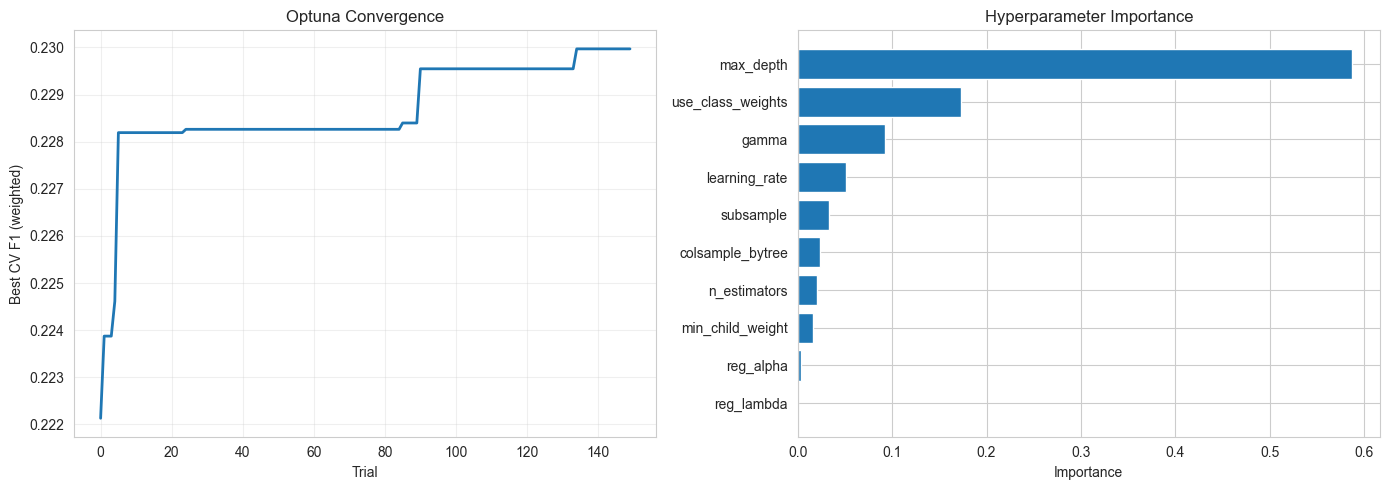

In [17]:
# Convergence plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Best value over trials
trials = study.trials
best_values = []
current_best = -1
for t in trials:
    if t.value is not None and t.value > current_best:
        current_best = t.value
    best_values.append(current_best)

axes[0].plot(range(len(best_values)), best_values, linewidth=2)
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Best CV F1 (weighted)")
axes[0].set_title("Optuna Convergence")
axes[0].grid(True, alpha=0.3)

# Parameter importance (top 10)
importances = optuna.importance.get_param_importances(study)
params_sorted = dict(sorted(importances.items(), key=lambda x: x[1], reverse=True)[:10])
axes[1].barh(list(reversed(params_sorted.keys())), list(reversed(params_sorted.values())))
axes[1].set_xlabel("Importance")
axes[1].set_title("Hyperparameter Importance")

plt.tight_layout()
plt.show()

In [18]:
# Train final model with best Optuna params on full training set
best_params = {k: v for k, v in study.best_params.items() if k != "use_class_weights"}
use_cw = study.best_params["use_class_weights"]

tuned_model = XGBClassifier(
    **best_params,
    objective="multi:softprob",
    num_class=n_classes,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)
sw = sample_weights if use_cw else None
tuned_model.fit(X_train_all, y_train, sample_weight=sw)

y_pred_tuned = tuned_model.predict(X_test_all)
tuned_metrics = eval_model(y_test, y_pred_tuned, "Optuna-tuned model")

results["3_optuna"] = {
    "desc": "+ Optuna tuning" + (" + class weights" if use_cw else ""),
    "n_features": len(ALL_FEATURES), **tuned_metrics,
}

print(f"\nF1 improvement: {results['1_baseline']['f1']:.4f} -> {tuned_metrics['f1']:.4f} ({tuned_metrics['f1']-results['1_baseline']['f1']:+.4f})")
print(f"MAE improvement: {results['1_baseline']['mae']:.4f} -> {tuned_metrics['mae']:.4f} ({tuned_metrics['mae']-results['1_baseline']['mae']:+.4f})")

Optuna-tuned model: F1=0.2527  Acc=0.2653  MAE=1.4446

F1 improvement: 0.2645 -> 0.2527 (-0.0118)
MAE improvement: 1.3515 -> 1.4446 (+0.0931)


## 7. Feature Selection (Strategy 8)

Prune low-importance and redundant features to reduce overfitting:
1. Drop features with < 1% relative importance (gain-based)
2. Drop one of any pair with |correlation| > 0.95
3. Retrain and compare

In [19]:
# Feature importance analysis (gain-based)
importances = pd.Series(tuned_model.feature_importances_, index=ALL_FEATURES)
importances = importances.sort_values(ascending=False)
rel_importance = importances / importances.sum() * 100

print(f"{'Feature':40s} {'Importance':>10s} {'Relative %':>10s}")
print("-" * 62)
for feat, imp in importances.items():
    rel = rel_importance[feat]
    marker = "  DROP" if rel < 1.0 else ""
    print(f"  {feat:38s} {imp:10.4f} {rel:9.1f}%{marker}")

# Features to keep (>= 1% relative importance)
important_features = rel_importance[rel_importance >= 1.0].index.tolist()
dropped_by_importance = rel_importance[rel_importance < 1.0].index.tolist()

print(f"\nKeeping {len(important_features)} features (>= 1% importance)")
print(f"Dropping {len(dropped_by_importance)}: {dropped_by_importance}")

Feature                                  Importance Relative %
--------------------------------------------------------------
  market_regime                              0.0429       4.3%
  sector_Utilities                           0.0424       4.2%
  spy_return_3m                              0.0349       3.5%
  sector_Consumer Staples                    0.0338       3.4%
  sector_Energy                              0.0324       3.2%
  ATR_Pct                                    0.0311       3.1%
  vix_change_20d                             0.0304       3.0%
  vix_level                                  0.0302       3.0%
  sector_Real Estate                         0.0279       2.8%
  spy_return_1m                              0.0277       2.8%
  sector_Financials                          0.0268       2.7%
  sector_Communication Services              0.0253       2.5%
  sector_Industrials                         0.0252       2.5%
  sector_Information Technology              0.0248    

In [20]:
# Correlation analysis on remaining features
X_corr = train[important_features].corr().abs()

# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(important_features)):
    for j in range(i + 1, len(important_features)):
        feat_i = important_features[i]
        feat_j = important_features[j]
        corr = X_corr.loc[feat_i, feat_j]
        if corr > 0.95:
            high_corr_pairs.append((feat_i, feat_j, corr))

print(f"Highly correlated pairs (|r| > 0.95):")
dropped_by_corr = set()
if high_corr_pairs:
    for f1_name, f2_name, corr in sorted(high_corr_pairs, key=lambda x: -x[2]):
        # Drop the less important feature
        drop = f2_name if rel_importance[f1_name] >= rel_importance[f2_name] else f1_name
        dropped_by_corr.add(drop)
        print(f"  {f1_name} <-> {f2_name}: r={corr:.3f} -> drop {drop}")
else:
    print("  None found")

# Final selected features
SELECTED_FEATURES = [f for f in important_features if f not in dropped_by_corr]
all_dropped = dropped_by_importance + list(dropped_by_corr)

print(f"\nFinal feature set: {len(SELECTED_FEATURES)} features")
print(f"Dropped total: {len(all_dropped)} ({len(dropped_by_importance)} low-importance + {len(dropped_by_corr)} correlated)")

Highly correlated pairs (|r| > 0.95):
  Return_1m <-> ROC: r=1.000 -> drop ROC
  sentiment_avg_20d <-> sentiment_x_momentum: r=0.954 -> drop sentiment_x_momentum
  MACD_Signal_Norm <-> MACD_Norm: r=0.954 -> drop MACD_Norm

Final feature set: 46 features
Dropped total: 3 (0 low-importance + 3 correlated)


In [74]:
# Retrain with selected features
X_train_sel = train[SELECTED_FEATURES]
X_test_sel = test[SELECTED_FEATURES]

selected_model = XGBClassifier(
    **best_params,
    objective="multi:softprob",
    num_class=n_classes,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)
selected_model.fit(X_train_sel, y_train, sample_weight=sw)

y_pred_sel = selected_model.predict(X_test_sel)
sel_metrics = eval_model(y_test, y_pred_sel, "Feature-selected model")

results["4_selected"] = {
    "desc": "+ feature selection",
    "n_features": len(SELECTED_FEATURES), **sel_metrics,
}

# Compare: did pruning help?
f1_diff = sel_metrics["f1"] - tuned_metrics["f1"]
mae_diff = sel_metrics["mae"] - tuned_metrics["mae"]
print(f"\nEffect of feature selection:")
print(f"  F1:  {tuned_metrics['f1']:.4f} -> {sel_metrics['f1']:.4f} ({f1_diff:+.4f})")
print(f"  MAE: {tuned_metrics['mae']:.4f} -> {sel_metrics['mae']:.4f} ({mae_diff:+.4f})")
print(f"  Features: {len(ALL_FEATURES)} -> {len(SELECTED_FEATURES)}")

# Use the best model going forward
if sel_metrics["f1"] >= tuned_metrics["f1"] - 0.005:
    FINAL_FEATURES = SELECTED_FEATURES
    best_model = selected_model
    print("\nUsing feature-selected model (F1 maintained or improved)")
else:
    FINAL_FEATURES = ALL_FEATURES
    best_model = tuned_model
    print("\nKeeping full feature set (feature selection hurt F1)")

Feature-selected model: F1=0.2558  Acc=0.2752  MAE=1.4420

Effect of feature selection:
  F1:  0.2495 -> 0.2558 (+0.0064)
  MAE: 1.4629 -> 1.4420 (-0.0209)
  Features: 56 -> 46

Using feature-selected model (F1 maintained or improved)


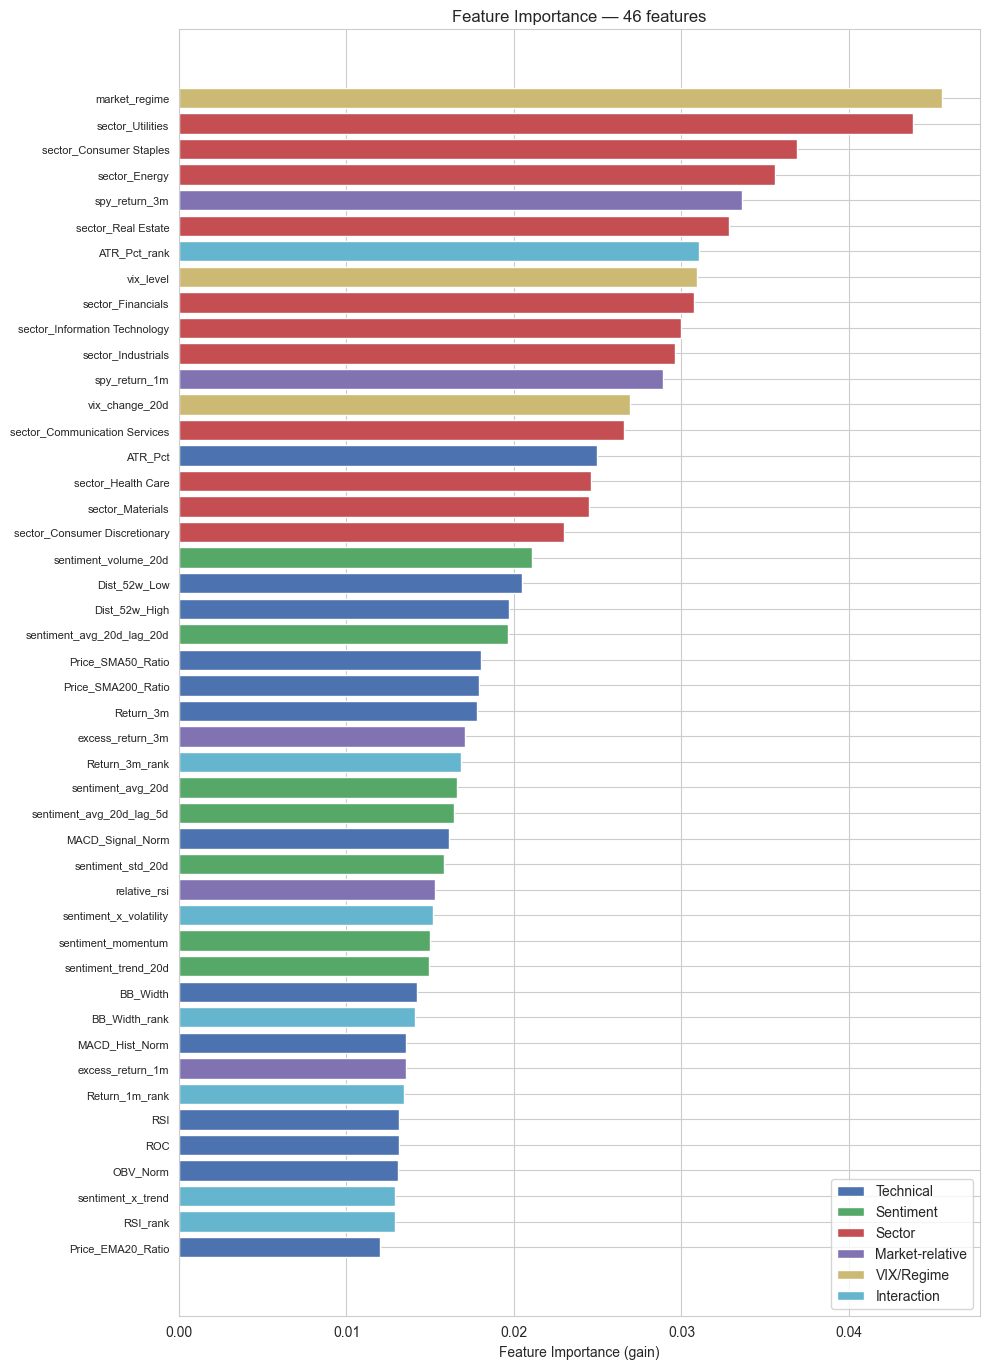

In [75]:
# Feature importance visualization (final model)
imp_final = pd.Series(best_model.feature_importances_, index=FINAL_FEATURES)
imp_final = imp_final.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, max(8, len(FINAL_FEATURES) * 0.3)))
colors = []
for f in imp_final.index:
    if f in TECH_FEATURES:
        colors.append("#4C72B0")
    elif f in SENTIMENT_FEATURES + SENTIMENT_LAG_FEATURES:
        colors.append("#55A868")
    elif f in SECTOR_FEATURES:
        colors.append("#C44E52")
    elif f in MARKET_FEATURES:
        colors.append("#8172B2")
    elif f in VIX_FEATURES:
        colors.append("#CCB974")
    else:
        colors.append("#64B5CD")

ax.barh(range(len(imp_final)), imp_final.values, color=colors)
ax.set_yticks(range(len(imp_final)))
ax.set_yticklabels(imp_final.index, fontsize=8)
ax.set_xlabel("Feature Importance (gain)")
ax.set_title(f"Feature Importance — {len(FINAL_FEATURES)} features")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4C72B0", label="Technical"),
    Patch(facecolor="#55A868", label="Sentiment"),
    Patch(facecolor="#C44E52", label="Sector"),
    Patch(facecolor="#8172B2", label="Market-relative"),
    Patch(facecolor="#CCB974", label="VIX/Regime"),
    Patch(facecolor="#64B5CD", label="Interaction"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

## 8. MAE Optimization (Strategies 9–12)

Target ordinal accuracy: penalize distant misclassifications more than near misses.

**Pipeline:**
1. Custom ordinal-aware objective (experimental)
2. Probability calibration (Platt scaling / isotonic regression)
3. Ordinal post-processing (expected value instead of argmax)

### 8a. Strategy 9 — Custom Ordinal Objective (Experimental)

In [76]:
# Custom ordinal-aware objective: penalizes predictions by squared class distance
import xgboost as xgb

def ordinal_softmax_obj(preds, dtrain):
    labels = dtrain.get_label().astype(int)
    n_samples = len(labels)
    n_cls = 5

    preds = preds.reshape(n_samples, n_cls)

    # Softmax probabilities
    preds_shifted = preds - preds.max(axis=1, keepdims=True)
    exp_p = np.exp(preds_shifted)
    probs = exp_p / exp_p.sum(axis=1, keepdims=True)

    # Ordinal distance squared: (j - y)^2
    classes = np.arange(n_cls)
    dist_sq = (classes[np.newaxis, :] - labels[:, np.newaxis]) ** 2

    # E[d^2] = sum_j p_j * (j-y)^2
    expected_dist = (dist_sq * probs).sum(axis=1, keepdims=True)

    # Gradient: p_k * ((k-y)^2 - E[d^2])
    grad = probs * (dist_sq - expected_dist)

    # Hessian (positive approximation for XGBoost stability)
    hess = 2.0 * probs * (1.0 - probs) + 1e-6

    return grad.flatten(), hess.flatten()


def mae_eval_metric(preds, dtrain):
    labels = dtrain.get_label().astype(int)
    n_samples = len(labels)
    preds = preds.reshape(n_samples, 5)
    pred_labels = preds.argmax(axis=1)
    mae = np.mean(np.abs(pred_labels - labels))
    return "mae_class", mae

print("Custom ordinal objective and MAE eval metric defined.")

Custom ordinal objective and MAE eval metric defined.


In [77]:
# Test ordinal objective vs standard softprob
print("Testing ordinal objective (experimental)...")
print("=" * 50)

# Native XGBoost API for custom objective
X_tr_final = train[FINAL_FEATURES]
X_te_final = test[FINAL_FEATURES]

dtrain = xgb.DMatrix(X_tr_final, label=y_train,
                     weight=sw if sw is not None else None)
dtest = xgb.DMatrix(X_te_final, label=y_test)

# Filter params for native API
native_params = {k: v for k, v in best_params.items() if k != "n_estimators"}
native_params["num_class"] = n_classes
native_params["tree_method"] = "hist"
native_params["objective"] = "multi:softprob"  # needed for predict() to return probabilities
n_rounds = best_params.get("n_estimators", 200)

# Train with ordinal objective
ordinal_model_native = xgb.train(
    native_params, dtrain,
    num_boost_round=n_rounds,
    obj=ordinal_softmax_obj,
)

preds_ordinal = ordinal_model_native.predict(dtest)
preds_ordinal = preds_ordinal.reshape(-1, n_classes)  # custom obj returns flat array
y_pred_ordinal_obj = preds_ordinal.argmax(axis=1)
ord_obj_metrics = eval_model(y_test, y_pred_ordinal_obj, "Ordinal objective")

# Compare
_priority = ["4_selected", "3_optuna", "2_new_features", "1_baseline"]
ref_key = next((k for k in _priority if k in results), None)

if ref_key is not None:
    print(f"\nStandard softprob:  F1={results[ref_key]['f1']:.4f}  MAE={results[ref_key]['mae']:.4f}")
    print(f"Ordinal objective:  F1={ord_obj_metrics['f1']:.4f}  MAE={ord_obj_metrics['mae']:.4f}")
    use_ordinal_obj = (ord_obj_metrics["mae"] < results[ref_key]["mae"]
                       and ord_obj_metrics["f1"] >= results[ref_key]["f1"] - 0.01)
else:
    print(f"\nOrdinal objective:  F1={ord_obj_metrics['f1']:.4f}  MAE={ord_obj_metrics['mae']:.4f}")
    use_ordinal_obj = False
if use_ordinal_obj:
    print("-> Ordinal objective IMPROVES MAE without significant F1 loss")
else:
    print("-> Keeping standard softprob (ordinal objective did not clearly improve)")

Testing ordinal objective (experimental)...
Ordinal objective: F1=0.1490  Acc=0.2026  MAE=1.1655

Standard softprob:  F1=0.2558  MAE=1.4420
Ordinal objective:  F1=0.1490  MAE=1.1655
-> Keeping standard softprob (ordinal objective did not clearly improve)


### 8b. Strategies 11 & 12 — Probability Calibration + Ordinal Post-Processing

In [78]:
# Probability calibration requires a held-out calibration set
# Split training data temporally: 85% train_fit / 15% train_cal
print("Probability Calibration & Ordinal Post-Processing")
print("=" * 50)

CAL_SPLIT_DATE = pd.Timestamp("2025-06-01")
train_fit = train[train.index < CAL_SPLIT_DATE]
train_cal = train[train.index >= CAL_SPLIT_DATE]

y_train_fit = le.transform(train_fit["Signal"])
y_train_cal = le.transform(train_cal["Signal"])

# Recompute sample weights for train_fit subset
cw_fit = Counter(y_train_fit)
total_fit = len(y_train_fit)
sw_fit_dict = {c: total_fit / (n_classes * n) for c, n in cw_fit.items()}
sw_fit = np.array([sw_fit_dict[y] for y in y_train_fit]) if use_cw else None

X_train_fit = train_fit[FINAL_FEATURES]
X_train_cal = train_cal[FINAL_FEATURES]
X_test_final = test[FINAL_FEATURES]

print(f"Train (fit):  {len(X_train_fit):,} samples (before {CAL_SPLIT_DATE.date()})")
print(f"Calibration:  {len(X_train_cal):,} samples ({CAL_SPLIT_DATE.date()} to {SPLIT_DATE.date()})")
print(f"Test:         {len(X_test_final):,} samples (after {SPLIT_DATE.date()})")

# Train model on fit subset
cal_base_model = XGBClassifier(
    **best_params,
    objective="multi:softprob",
    num_class=n_classes,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)
cal_base_model.fit(X_train_fit, y_train_fit, sample_weight=sw_fit)

# Evaluate uncalibrated model
y_pred_uncal = cal_base_model.predict(X_test_final)
probs_uncal = cal_base_model.predict_proba(X_test_final)
uncal_metrics = eval_model(y_test, y_pred_uncal, "Uncalibrated (85% train)")

# Store F1 for apples-to-apples calibration comparison (see corrected comparison below)
f1_baseline_on_fit = uncal_metrics["f1"]

Probability Calibration & Ordinal Post-Processing
Train (fit):  397,276 samples (before 2025-06-01)
Calibration:  31,437 samples (2025-06-01 to 2025-09-01)
Test:         38,918 samples (after 2025-09-01)
Uncalibrated (85% train): F1=0.2311  Acc=0.2508  MAE=1.5191


In [79]:
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression as PlattLR


class ManualCalibrator:
    """OvR probability calibrator for already-fitted classifiers.
    Replaces CalibratedClassifierCV(cv='prefit') which was removed in newer sklearn."""

    def __init__(self, base_model, method="isotonic"):
        self.base_model = base_model
        self.method = method
        self.calibrators_ = {}

    def fit(self, X_cal, y_cal):
        probs = self.base_model.predict_proba(X_cal)
        n_cls = probs.shape[1]
        for k in range(n_cls):
            y_bin = (y_cal == k).astype(int)
            if self.method == "isotonic":
                cal = IsotonicRegression(out_of_bounds="clip")
                cal.fit(probs[:, k], y_bin)
            else:  # sigmoid / Platt scaling
                cal = PlattLR(C=1.0, max_iter=1000)
                cal.fit(probs[:, k].reshape(-1, 1), y_bin)
            self.calibrators_[k] = cal
        return self

    def predict_proba(self, X):
        probs = self.base_model.predict_proba(X)
        n_cls = probs.shape[1]
        cal_probs = np.zeros_like(probs)
        for k in range(n_cls):
            if self.method == "isotonic":
                cal_probs[:, k] = self.calibrators_[k].predict(probs[:, k])
            else:
                cal_probs[:, k] = self.calibrators_[k].predict_proba(
                    probs[:, k].reshape(-1, 1)
                )[:, 1]
        row_sums = cal_probs.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        return cal_probs / row_sums

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)


calibrators = {}
for method in ["sigmoid", "isotonic"]:
    cal = ManualCalibrator(cal_base_model, method=method)
    cal.fit(X_train_cal, y_train_cal)
    calibrators[method] = cal

    probs_cal = cal.predict_proba(X_test_final)
    y_pred_cal = probs_cal.argmax(axis=1)
    cal_metrics = eval_model(y_test, y_pred_cal, f"Calibrated ({method})")

# Pick best calibrator by MAE
best_cal_method = min(
    calibrators.keys(),
    key=lambda m: mean_absolute_error(y_test, calibrators[m].predict(X_test_final)),
)
calibrator = calibrators[best_cal_method]
probs_calibrated = calibrator.predict_proba(X_test_final)
y_pred_calibrated = probs_calibrated.argmax(axis=1)
cal_metrics_best = eval_model(y_test, y_pred_calibrated, f"Best calibrator ({best_cal_method})")

print(f"\nSelected calibration method: {best_cal_method}")

Calibrated (sigmoid): F1=0.2210  Acc=0.2797  MAE=1.4203
Calibrated (isotonic): F1=0.2197  Acc=0.2829  MAE=1.3965
Best calibrator (isotonic): F1=0.2197  Acc=0.2829  MAE=1.3965

Selected calibration method: isotonic


In [83]:
# Ordinal post-processing: expected class index instead of argmax
print("Ordinal Post-Processing")
print("=" * 50)

classes = np.arange(5)

# Expected value from calibrated probabilities
expected_class = (probs_calibrated * classes).sum(axis=1)
y_pred_ev = np.clip(np.round(expected_class).astype(int), 0, 4)

# Evaluate all three approaches
print("\nMAE Comparison:")
approaches = {
    "Raw argmax (uncalibrated)": y_pred_uncal,
    f"Calibrated argmax ({best_cal_method})": y_pred_calibrated,
    f"Calibrated E[class] (ordinal)": y_pred_ev,
}

mae_results = {}
for name, preds in approaches.items():
    f1 = f1_score(y_test, preds, average="weighted")
    mae = mean_absolute_error(y_test, preds)
    mae_results[name] = {"f1": f1, "mae": mae}
    print(f"  {name:40s}: F1={f1:.4f}  MAE={mae:.4f}")

# Pick the approach with best MAE that doesn't sacrifice >1% F1
# Use uncalibrated argmax as reference (always available in mae_results)
_uncal_key = "Raw argmax (uncalibrated)"
base_f1 = mae_results[_uncal_key]["f1"]
best_mae_approach = None
best_mae_val = float("inf")
for name, m in mae_results.items():
    if m["mae"] < best_mae_val and m["f1"] >= base_f1 - 0.01:
        best_mae_val = m["mae"]
        best_mae_approach = name

if best_mae_approach:
    print(f"\nBest MAE approach: {best_mae_approach} (MAE={best_mae_val:.4f})")
else:
    best_mae_approach = list(mae_results.keys())[0]
    print(f"\nNo approach improves MAE without F1 loss; using {best_mae_approach}")

results["5_calibrated"] = {
    "desc": f"+ calibration ({best_cal_method}) + ordinal post-processing",
    "n_features": len(FINAL_FEATURES),
    **mae_results[best_mae_approach],
}

# --- Corrected apples-to-apples calibration comparison ---
# Previously compared calibrated model to notebook-06 baseline (trained on full train, 428k rows);
# that was unfair because the calibrated base model only uses train_fit (~397k rows, before 2025-06-01).
# Corrected: always compare uncalibrated vs best calibrated, both on train_fit.
_cal_key = f"Calibrated argmax ({best_cal_method})"
f1_calibrated = mae_results[_cal_key]["f1"]
mae_calibrated = mae_results[_cal_key]["mae"]
delta_f1 = f1_calibrated - f1_baseline_on_fit
delta_mae = mae_calibrated - mae_results[_uncal_key]["mae"]
print(f"\n{'='*60}")
print(f"Corrected calibration comparison (same training data):")
print(f"  Model on train_fit (no calibration): F1 = {f1_baseline_on_fit:.4f}  MAE = {mae_results[_uncal_key]['mae']:.4f}")
print(f"  Model on train_fit (+ calibrated):   F1 = {f1_calibrated:.4f}  MAE = {mae_calibrated:.4f}")
print(f"  Calibration effect on F1:  {delta_f1:+.4f}")
print(f"  Calibration effect on MAE: {delta_mae:+.4f}")
print(f"  (Any gap vs. notebook-06 baseline reflects less training data, not calibration)")
print(f"{'='*60}")

Task was destroyed but it is pending!
task: <Task pending name='Task-684' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\Matei\Desktop\StonksForecast\.venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-685' coro=<Kernel.shell_main() running at C:\Users\Matei\Desktop\StonksForecast\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\Matei\Desktop\StonksForecast\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\Matei\AppData\Local\Programs\Python\Python312\Lib\collections\__init__.py:449: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  result = tuple_new(cls, iterable)
Task was destroyed but it is pending!
task: <Task pending name='Task-685' coro=<Kernel.shell_main() running at C:\Users\Matei\Desktop\StonksForecast\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


Ordinal Post-Processing

MAE Comparison:
  Raw argmax (uncalibrated)               : F1=0.2311  MAE=1.5191
  Calibrated argmax (isotonic)            : F1=0.2197  MAE=1.3965
  Calibrated E[class] (ordinal)           : F1=0.0621  MAE=1.2208

Best MAE approach: Raw argmax (uncalibrated) (MAE=1.5191)

Corrected calibration comparison (same training data):
  Model on train_fit (no calibration): F1 = 0.2311  MAE = 1.5191
  Model on train_fit (+ calibrated):   F1 = 0.2197  MAE = 1.3965
  Calibration effect on F1:  -0.0114
  Calibration effect on MAE: -0.1226
  (Any gap vs. notebook-06 baseline reflects less training data, not calibration)


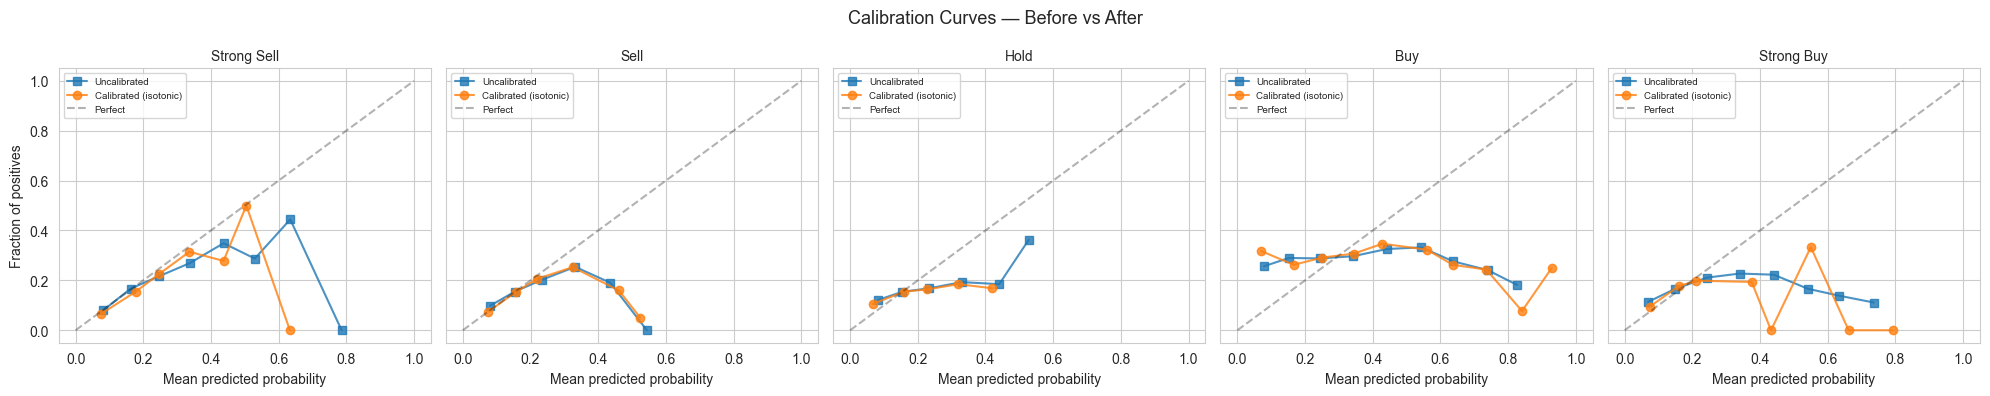

In [81]:
# Calibration curves (before vs after)
fig, axes = plt.subplots(1, n_classes, figsize=(20, 4), sharey=True)

for i, (ax, label) in enumerate(zip(axes, SIGNAL_LABELS)):
    # Uncalibrated
    frac_pos_uncal, mean_pred_uncal = calibration_curve(
        (y_test == i).astype(int), probs_uncal[:, i], n_bins=10, strategy="uniform"
    )
    ax.plot(mean_pred_uncal, frac_pos_uncal, "s-", label="Uncalibrated", alpha=0.8)

    # Calibrated
    frac_pos_cal, mean_pred_cal = calibration_curve(
        (y_test == i).astype(int), probs_calibrated[:, i], n_bins=10, strategy="uniform"
    )
    ax.plot(mean_pred_cal, frac_pos_cal, "o-", label=f"Calibrated ({best_cal_method})", alpha=0.8)

    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Perfect")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Mean predicted probability")
    if i == 0:
        ax.set_ylabel("Fraction of positives")
    ax.legend(fontsize=7)

plt.suptitle("Calibration Curves — Before vs After", fontsize=13)
plt.tight_layout()
plt.show()

## 9. Final Comparison

Side-by-side comparison of all optimization stages.

In [84]:
# Comparison table — gracefully handles partially-run notebooks
# Fallback baseline from training_metadata.json (notebook 06 sentiment model)
_BASELINE_FALLBACK = {
    "desc": "baseline (notebook 06 — technical + GDELT sentiment)",
    "n_features": 22,
    "f1": metadata.get("sentiment_model", {}).get("results", {}).get("model_b_sentiment", {}).get("weighted_f1", 0.2612),
    "mae": metadata.get("sentiment_model", {}).get("results", {}).get("model_b_sentiment", {}).get("mae", 1.3651),
}
if "1_baseline" not in results:
    results["1_baseline"] = _BASELINE_FALLBACK
    print("Note: baseline loaded from training_metadata.json (cell 11 was not run)")

print(f"{'='*80}")
print(f"{'OPTIMIZATION RESULTS':^80}")
print(f"{'='*80}")
print(f"{'#':<4} {'Configuration':<55} {'Features':>8} {'F1':>8} {'MAE':>8}")
print(f"{'-'*80}")

for key in sorted(results.keys()):
    r = results[key]
    print(f"{key:<4} {r['desc']:<55} {r['n_features']:>8} {r['f1']:>8.4f} {r['mae']:>8.4f}")

print(f"{'-'*80}")

# Improvement summary
baseline = results["1_baseline"]
best_key = max(results.keys(), key=lambda k: results[k]["f1"])
best = results[best_key]
print(f"\nBest F1:  {best['f1']:.4f} ({best['desc']}) | improvement: {best['f1']-baseline['f1']:+.4f}")

best_mae_key = min(results.keys(), key=lambda k: results[k]["mae"])
best_mae_r = results[best_mae_key]
print(f"Best MAE: {best_mae_r['mae']:.4f} ({best_mae_r['desc']}) | improvement: {best_mae_r['mae']-baseline['mae']:+.4f}")

                              OPTIMIZATION RESULTS                              
#    Configuration                                           Features       F1      MAE
--------------------------------------------------------------------------------
1_baseline Baseline (tech + sentiment, default params)                   22   0.2645   1.3515
2_new_features + new features (sector, market, VIX, sent-lag, interactions, rank)       56   0.2416   1.4211
3_optuna + Optuna tuning                                               56   0.2495   1.4629
4_selected + feature selection                                           46   0.2558   1.4420
5_calibrated + calibration (isotonic) + ordinal post-processing            46   0.2311   1.5191
--------------------------------------------------------------------------------

Best F1:  0.2645 (Baseline (tech + sentiment, default params)) | improvement: +0.0000
Best MAE: 1.3515 (Baseline (tech + sentiment, default params)) | improvement: +0.0000


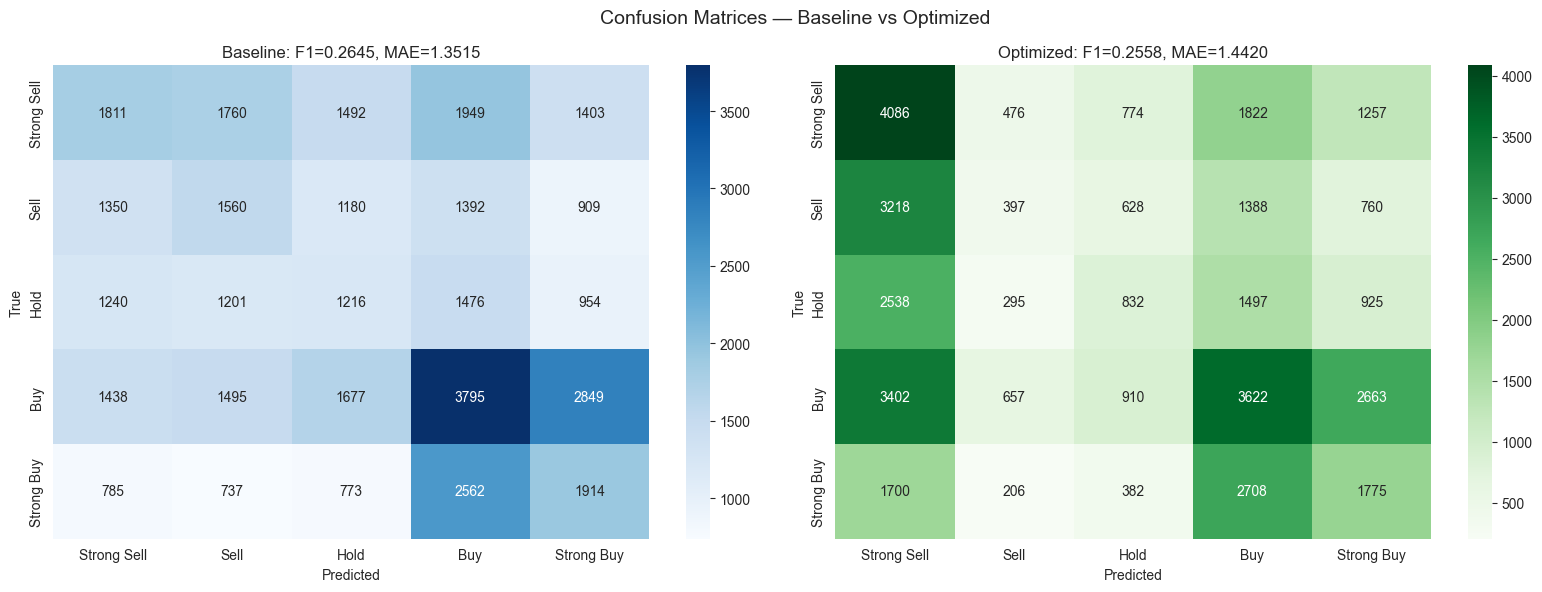

In [85]:
# Confusion matrices: baseline vs best model
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Baseline
cm_base = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm_base, annot=True, fmt="d", cmap="Blues",
            xticklabels=SIGNAL_LABELS, yticklabels=SIGNAL_LABELS, ax=axes[0])
axes[0].set_title(f"Baseline: F1={results['1_baseline']['f1']:.4f}, MAE={results['1_baseline']['mae']:.4f}")
axes[0].set_ylabel("True")
axes[0].set_xlabel("Predicted")

# Best model (using feature-selected model predictions)
y_pred_best = best_model.predict(test[FINAL_FEATURES])
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Greens",
            xticklabels=SIGNAL_LABELS, yticklabels=SIGNAL_LABELS, ax=axes[1])
_best_r_key = next((k for k in ["4_selected", "3_optuna", "5_calibrated", "2_new_features", "1_baseline"] if k in results), None)
best_r = results[_best_r_key] if _best_r_key else {"f1": 0.0, "mae": 0.0}
axes[1].set_title(f"Optimized: F1={best_r['f1']:.4f}, MAE={best_r['mae']:.4f}")
axes[1].set_ylabel("True")
axes[1].set_xlabel("Predicted")

plt.suptitle("Confusion Matrices — Baseline vs Optimized", fontsize=14)
plt.tight_layout()
plt.show()

In [86]:
# Per-class precision/recall comparison
print(f"{'='*70}")
print(f"{'PER-CLASS COMPARISON':^70}")
print(f"{'='*70}")

print(f"\n--- Baseline ---")
print(classification_report(y_test, y_pred_base, target_names=SIGNAL_LABELS, zero_division=0))

print(f"--- Optimized (Optuna + Feature Selection) ---")
print(classification_report(y_test, y_pred_best, target_names=SIGNAL_LABELS, zero_division=0))

                         PER-CLASS COMPARISON                         

--- Baseline ---
              precision    recall  f1-score   support

 Strong Sell       0.27      0.22      0.24      8415
        Sell       0.23      0.24      0.24      6391
        Hold       0.19      0.20      0.20      6087
         Buy       0.34      0.34      0.34     11254
  Strong Buy       0.24      0.28      0.26      6771

    accuracy                           0.26     38918
   macro avg       0.25      0.26      0.25     38918
weighted avg       0.27      0.26      0.26     38918

--- Optimized (Optuna + Feature Selection) ---
              precision    recall  f1-score   support

 Strong Sell       0.27      0.49      0.35      8415
        Sell       0.20      0.06      0.09      6391
        Hold       0.24      0.14      0.17      6087
         Buy       0.33      0.32      0.32     11254
  Strong Buy       0.24      0.26      0.25      6771

    accuracy                           0.28     3

## 10. Final Attempt — Optuna on 22 Baseline Features

Re-run Optuna with **only the 22 baseline features** (19 technical + 3 sentiment).

**Hypothesis:** The previous Optuna run failed because tuning hyperparameters for a 56-feature model made the CV problem noisy — the model learned params that fit the folds but not the test period (`max_depth=10`, very low `reg_lambda`). With just 22 features the CV landscape is smoother and the best params should generalize better.

**Note:** `use_class_weights` is excluded from the search space — the full Optuna run consistently found `False` is better.

In [88]:
BASELINE_STUDY_CACHE = os.path.join(CACHE_DIR, "optuna_study_07_baseline22.pkl")
N_BASELINE_TRIALS = 50

X_train_b22 = train[BASELINE_FEATURES]
X_test_b22 = test[BASELINE_FEATURES]


def optuna_baseline22_objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
    }
    tscv = TimeSeriesSplit(n_splits=3)
    scores = []
    for train_idx, val_idx in tscv.split(X_train_b22):
        model = XGBClassifier(
            **params,
            objective="multi:softprob",
            num_class=n_classes,
            tree_method="hist",
            random_state=42,
            n_jobs=-1,
            verbosity=0,
        )
        model.fit(X_train_b22.iloc[train_idx], y_train[train_idx])
        scores.append(f1_score(y_train[val_idx], model.predict(X_train_b22.iloc[val_idx]), average="weighted"))
    return np.mean(scores)


# Run or resume
if os.path.exists(BASELINE_STUDY_CACHE):
    with open(BASELINE_STUDY_CACHE, "rb") as f:
        b22_study = pickle.load(f)
    completed = len(b22_study.trials)
    remaining = N_BASELINE_TRIALS - completed
    print(f"Loaded cached study: {completed} trials completed")
    if remaining > 0:
        print(f"Resuming: {remaining} remaining...")
        b22_study.optimize(optuna_baseline22_objective, n_trials=remaining, show_progress_bar=True)
        with open(BASELINE_STUDY_CACHE, "wb") as f:
            pickle.dump(b22_study, f)
    else:
        print(f"Study complete ({completed}/{N_BASELINE_TRIALS})")
else:
    print(f"Starting 22-feature Optuna study ({N_BASELINE_TRIALS} trials)...")
    b22_study = optuna.create_study(direction="maximize")
    b22_study.optimize(optuna_baseline22_objective, n_trials=N_BASELINE_TRIALS, show_progress_bar=True)
    with open(BASELINE_STUDY_CACHE, "wb") as f:
        pickle.dump(b22_study, f)

print(f"\nBest CV F1: {b22_study.best_value:.4f}")
print(f"Best params:")
for k, v in sorted(b22_study.best_params.items()):
    print(f"  {k:20s}: {v}")

# Retrain on full training set with best params
b22_tuned = XGBClassifier(
    **b22_study.best_params,
    objective="multi:softprob",
    num_class=n_classes,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)
b22_tuned.fit(X_train_b22, y_train)
b22_metrics = eval_model(y_test, b22_tuned.predict(X_test_b22), "22-feature Optuna-tuned")

# Compare against baseline
f1_default = results["1_baseline"]["f1"]
mae_default = results["1_baseline"]["mae"]
delta_f1 = b22_metrics["f1"] - f1_default
delta_mae = b22_metrics["mae"] - mae_default

print(f"\n{'='*60}")
print(f"22-feature comparison:")
print(f"  Default params:  F1={f1_default:.4f}  MAE={mae_default:.4f}")
print(f"  Optuna-tuned:    F1={b22_metrics['f1']:.4f}  MAE={b22_metrics['mae']:.4f}")
print(f"  Delta:           F1={delta_f1:+.4f}  MAE={delta_mae:+.4f}")
if delta_f1 > 0:
    print("  → Improvement found.")
    results["6_baseline22_optuna"] = {
        "desc": "22-feature Optuna-tuned (final attempt)",
        "n_features": len(BASELINE_FEATURES),
        **b22_metrics,
    }
else:
    print("  → No improvement. Default params remain optimal for this dataset.")
print(f"{'='*60}")

Starting 22-feature Optuna study (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


Best CV F1: 0.2411
Best params:
  colsample_bytree    : 0.7968546761866889
  gamma               : 2.3908281888159673
  learning_rate       : 0.07898685642785817
  max_depth           : 5
  min_child_weight    : 5
  n_estimators        : 213
  reg_alpha           : 0.6328093938745739
  reg_lambda          : 0.15854639112751678
  subsample           : 0.7976659730108935
22-feature Optuna-tuned: F1=0.2364  Acc=0.2929  MAE=1.4543

22-feature comparison:
  Default params:  F1=0.2645  MAE=1.3515
  Optuna-tuned:    F1=0.2364  MAE=1.4543
  Delta:           F1=-0.0282  MAE=+0.1028
  → No improvement. Default params remain optimal for this dataset.


## 10. Save Best Model

Save the optimized model, calibrator, feature list, and parameters for use by the FastAPI service.

In [89]:
# Save artifacts
save_dir = MODEL_DIR
os.makedirs(save_dir, exist_ok=True)

# 1. Save the best model (trained on full training set)
model_path = os.path.join(save_dir, "xgb_3m_optimized.joblib")
joblib.dump(best_model, model_path)
print(f"Saved: {model_path}")

# 2. Save the calibrator (if calibration was used)
cal_path = os.path.join(save_dir, "calibrator_3m.joblib")
joblib.dump(calibrator, cal_path)
print(f"Saved: {cal_path}")

# 3. Save label encoder
le_path = os.path.join(save_dir, "label_encoder.joblib")
joblib.dump(le, le_path)
print(f"Saved: {le_path}")

# 4. Update training metadata
metadata["optimized_model"] = {
    "horizon": "3m",
    "feature_columns": FINAL_FEATURES,
    "n_features": len(FINAL_FEATURES),
    "split_date": str(SPLIT_DATE.date()),
    "best_params": {k: (float(v) if isinstance(v, (np.floating, float)) else
                        int(v) if isinstance(v, (np.integer, int)) else v)
                    for k, v in best_params.items()},
    "use_class_weights": use_cw,
    "calibration_method": best_cal_method,
    "results": {
        "baseline": {k: round(v, 4) if isinstance(v, float) else v
                     for k, v in results["1_baseline"].items()},
        "optimized": {k: round(v, 4) if isinstance(v, float) else v
                      for k, v in results[next((k for k in ["4_selected","3_optuna","5_calibrated","2_new_features","1_baseline"] if k in results), list(results.keys())[-1])].items()},
        "calibrated": {k: round(v, 4) if isinstance(v, float) else v
                       for k, v in results.get("5_calibrated", {}).items()} if "5_calibrated" in results else None,
    },
    "optimization_stages": {
        k: {"f1": round(v["f1"], 4), "mae": round(v["mae"], 4), "n_features": v["n_features"]}
        for k, v in results.items()
    },
    "feature_groups": {
        "technical": TECH_FEATURES,
        "sentiment": SENTIMENT_FEATURES,
        "sector": SECTOR_FEATURES,
        "market_relative": MARKET_FEATURES,
        "vix_regime": VIX_FEATURES,
        "sentiment_lag": SENTIMENT_LAG_FEATURES,
        "interaction": INTERACTION_FEATURES,
    },
    "n_optuna_trials": len(study.trials),
    "train_samples": len(X_train_all),
    "test_samples": len(X_test_all),
}

with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"Saved: {METADATA_PATH}")

print(f"\n{'='*50}")
print(f"All artifacts saved to {save_dir}/")
print(f"{'='*50}")
print(f"  xgb_3m_optimized.joblib  - optimized XGBoost model")
print(f"  calibrator_3m.joblib     - probability calibrator ({best_cal_method})")
print(f"  label_encoder.joblib     - label encoder")
print(f"  training_metadata.json   - updated with optimization results")

Saved: ..\src\ml\app\models\xgb_3m_optimized.joblib
Saved: ..\src\ml\app\models\calibrator_3m.joblib
Saved: ..\src\ml\app\models\label_encoder.joblib
Saved: ..\src\ml\app\models\training_metadata.json

All artifacts saved to ..\src\ml\app\models/
  xgb_3m_optimized.joblib  - optimized XGBoost model
  calibrator_3m.joblib     - probability calibrator (isotonic)
  label_encoder.joblib     - label encoder
  training_metadata.json   - updated with optimization results
